# Heinz Logistics

Wait or Ship?

**First function**: Generating x days (rounded up to a full week) of data

## Description Freight Simulation

The script simulates daily freight arrivals (brutto weight in kg and volume in cbm) using a statistical model fitted on 91 days of historical data.

**How it works:**

The model has three layers. First, it recognises that not every day has freight — so for each weekday it calculates the historical probability of a zero-freight day and samples that explicitly (zero-inflated model). Second, for days that do have freight, it fits a Gamma distribution per weekday to capture the fact that e.g. Sundays tend to be heavier than Tuesdays. Third, weight and cbm are not simulated independently — they are correlated via a Gaussian copula, which preserves the historical relationship between the two without forcing a fixed kg/cbm ratio.

**How to use it:**

Call the following function:

pythonscenarios = run_scenarios(n_simulations=100, n_days=91)

This returns a list of DataFrames, one per simulation run. Each DataFrame has four columns: Day, Weekday, Brutto_Weight_kg, and Cbm. The number of days is always rounded up to a full week (Tuesday–Monday). Each run uses a different random seed so the results vary, but any individual run is fully reproducible by seed.

In [2]:
"""
Monte Carlo Freight Simulation
================================
Simulates daily Brutto Weight (kg) and Cbm for a logistics operation.

Model details:
  - Zero-inflated Gamma per weekday:
      * p_zero  : empirical probability of a zero-freight day, fitted per weekday
      * Gamma   : shape & scale fitted on non-zero days only, per weekday
  - Weight / Cbm correlation:
      * Preserved via a Gaussian copula fitted on log-transformed non-zero pairs
      * The marginal Gamma draws are rank-correlated so the joint structure
        matches history without forcing a fixed kg/cbm ratio
  - Simulation period:
      * Always starts on Tuesday and ends on Monday
      * Input x (days) is silently rounded up to the next multiple of 7

Dependencies: pandas, numpy, scipy
"""

import math
import numpy as np
import pandas as pd
from scipy import stats
from typing import Optional


# ---------------------------------------------------------------------------
# 1.  Fit model parameters from historical data
# ---------------------------------------------------------------------------

def fit_model(df: pd.DataFrame) -> dict:
    """
    Fit per-weekday zero-inflated Gamma parameters and the log-space
    Gaussian copula correlation between Brutto Weight and Cbm.

    Parameters
    ----------
    df : pd.DataFrame
        Historical data with columns:
        'Weekday', 'Brutto Weight', 'Cbm'
        Weekday values must be full English names
        ('Tuesday', 'Wednesday', ..., 'Monday').

    Returns
    -------
    params : dict  – model parameters consumed by simulate()
    """
    WEEKDAY_ORDER = ['Tuesday', 'Wednesday', 'Thursday',
                     'Friday', 'Saturday', 'Sunday', 'Monday']

    params = {'weekday_order': WEEKDAY_ORDER, 'by_weekday': {}}

    # --- per-weekday Gamma + zero probability ---
    for wd in WEEKDAY_ORDER:
        sub   = df[df['Weekday'] == wd]
        n_tot = len(sub)
        nz    = sub[(sub['Brutto Weight'] > 0) & (sub['Cbm'] > 0)]
        n_nz  = len(nz)

        p_zero = 1.0 - n_nz / n_tot if n_tot > 0 else 0.0

        # Gamma on weight (floc=0 keeps support on (0, inf))
        if n_nz >= 2:
            w_shape, _, w_scale = stats.gamma.fit(nz['Brutto Weight'], floc=0)
            c_shape, _, c_scale = stats.gamma.fit(nz['Cbm'],           floc=0)
        else:                          # fallback: use global non-zero data
            all_nz = df[(df['Brutto Weight'] > 0) & (df['Cbm'] > 0)]
            w_shape, _, w_scale = stats.gamma.fit(all_nz['Brutto Weight'], floc=0)
            c_shape, _, c_scale = stats.gamma.fit(all_nz['Cbm'],           floc=0)

        params['by_weekday'][wd] = {
            'p_zero' : p_zero,
            'w_shape': w_shape, 'w_scale': w_scale,
            'c_shape': c_shape, 'c_scale': c_scale,
        }

    # --- Gaussian copula: Spearman rank correlation on ALL non-zero days ---
    # Using log-space makes the bivariate relationship closer to normal,
    # but the copula itself is rank-based so it works on any marginals.
    nz_all = df[(df['Brutto Weight'] > 0) & (df['Cbm'] > 0)].copy()
    if len(nz_all) >= 4:
        rho, _ = stats.spearmanr(np.log(nz_all['Brutto Weight']),
                                 np.log(nz_all['Cbm']))
        # Convert Spearman rho -> Pearson rho for the normal copula
        rho_pearson = 2 * np.sin(rho * math.pi / 6)
    else:
        rho_pearson = 0.95   # sensible logistics default

    # Clamp to valid correlation matrix range
    rho_pearson = float(np.clip(rho_pearson, -0.9999, 0.9999))
    params['copula_rho'] = rho_pearson

    return params


# ---------------------------------------------------------------------------
# 2.  Core simulation
# ---------------------------------------------------------------------------

def simulate(x: int,
             params: dict,
             seed: Optional[int] = None) -> pd.DataFrame:
    """
    Run one Monte Carlo simulation for x days (rounded up to a multiple of 7).

    Parameters
    ----------
    x      : int   – desired number of days (≥ 1)
    params : dict  – output of fit_model()
    seed   : int | None – random seed for reproducibility

    Returns
    -------
    pd.DataFrame with columns:
        Day         – 1, 2, 3, …
        Weekday     – 'Tu', 'We', 'Th', 'Fr', 'Sa', 'Su', 'Mo'
        Brutto_Weight_kg – simulated brutto weight (rounded to whole kg)
        Cbm         – simulated volume (rounded to 2 decimals)
    """
    if x < 1:
        raise ValueError("x must be at least 1")

    rng = np.random.default_rng(seed)

    # Round up to next multiple of 7
    n_days = math.ceil(x / 7) * 7

    WEEKDAY_ORDER = params['weekday_order']
    SHORT = {'Tuesday':   'Tu', 'Wednesday': 'We', 'Thursday':  'Th',
             'Friday':    'Fr', 'Saturday':  'Sa', 'Sunday':    'Su',
             'Monday':    'Mo'}

    rho = params['copula_rho']

    # Cholesky decomposition for correlated standard normals
    cov = np.array([[1.0, rho],
                    [rho, 1.0]])
    L   = np.linalg.cholesky(cov)

    rows = []
    for i in range(n_days):
        wd     = WEEKDAY_ORDER[i % 7]
        p      = params['by_weekday'][wd]
        day_no = i + 1

        # --- zero-inflation ---
        if rng.random() < p['p_zero']:
            weight = 0
            cbm    = 0.0
        else:
            # Draw two correlated standard normals via copula
            z      = L @ rng.standard_normal(2)          # shape (2,)
            u_w, u_c = stats.norm.cdf(z[0]), stats.norm.cdf(z[1])

            # Map uniform marginals -> Gamma quantiles
            weight = stats.gamma.ppf(u_w, a=p['w_shape'], scale=p['w_scale'])
            cbm    = stats.gamma.ppf(u_c, a=p['c_shape'], scale=p['c_scale'])

            # Rounding
            weight = max(1, round(float(weight)))        # whole kg, min 1
            cbm    = max(0.01, round(float(cbm), 2))     # 2 decimals, min 0.01

        rows.append({
            'Day'             : day_no,
            'Weekday'         : SHORT[wd],
            'Brutto_Weight_kg': weight,
            'Cbm'             : cbm,
        })

    return pd.DataFrame(rows)



# ---------------------------------------------------------------------------
# 3.  Scenario runner
# ---------------------------------------------------------------------------

def run_scenarios(n_simulations: int, n_days: int) -> list:
    """
    Run multiple simulations with the same fitted parameters.

    Parameters
    ----------
    n_simulations : int  – number of simulation runs
    n_days        : int  – number of days per run (rounded up to multiple of 7)

    Returns
    -------
    list of pd.DataFrames, one per simulation run
    """
    df     = pd.read_csv('Database.csv', sep=';')
    params = fit_model(df)

    results = []
    for i in range(n_simulations):
        sim = simulate(x=n_days, params=params, seed=i)
        results.append(sim)
    return results

### Test

In [3]:
run_scenarios(1, 365)


[     Day Weekday  Brutto_Weight_kg    Cbm
 0      1      Tu               727   5.58
 1      2      We                 0   0.00
 2      3      Th              2044  17.37
 3      4      Fr               398   1.44
 4      5      Sa              2620   7.17
 ..   ...     ...               ...    ...
 366  367      Th              3895  34.71
 367  368      Fr               291   2.18
 368  369      Sa                 0   0.00
 369  370      Su              1896   9.06
 370  371      Mo              1625   6.93
 
 [371 rows x 4 columns]]

## Cost structure

The following function displays the cost structure and allows to update it.


In [ ]:
def configure_costs() -> dict:
    """
    Interactive cost configurator for warehouse storage and transport costs.
    Displays defaults and allows the user to override any value.
    Run this cell independently in your notebook to update cost parameters.
    
    Returns
    -------
    dict with keys:
        'storage'   : storage cost tiers
        'intermodal': container options
        'ltl'       : LTL breakpoints as list of (max_kg, price_eur) tuples
    """

    # ------------------------------------------------------------------ #
    #  DEFAULTS                                                            #
    # ------------------------------------------------------------------ #
    defaults = {
        'storage': {
            'free_days'     : 3,          # days 1-3: free
            'tier1_days'    : (4, 7),     # days 4-7
            'tier1_rate'    : 2.50,       # €/w/m per day
            'tier2_day_from': 8,          # day 8 onward
            'tier2_rate'    : 4.00,       # €/w/m per day
        },
        'intermodal': {
            '20GP': {
                'cost_eur'  : 1145,
                'max_kg'    : 20_000,
                'max_cbm'   : 33,
            },
            '40HQ': {
                'cost_eur'  : 1645,
                'max_kg'    : 24_000,
                'max_cbm'   : 76,
            },
        },
        'ltl': [
            #  (max_kg_breakpoint, price_eur)
            (100,   146),
            (500,   285),
            (1_000,  513),
            (2_000,  616),
            (3_000, 1_069),
            (4_000, 1_494),
            (5_000, 1_522),
            (6_000, 1_782),
            (8_000, 1_878),
            (13_000, 1_956),
            (20_000, 2_085),
        ],
    }

    import copy
    costs = copy.deepcopy(defaults)

    # ------------------------------------------------------------------ #
    #  HELPERS                                                             #
    # ------------------------------------------------------------------ #
    def _ask(prompt: str, cast, current):
        """Prompt user; return cast(input) or current on empty/invalid."""
        try:
            raw = input(prompt).strip()
            return cast(raw) if raw else current
        except (ValueError, TypeError):
            print("  ⚠  Invalid input – keeping current value.")
            return current

    def _section(title: str):
        print(f"\n{'═'*55}")
        print(f"  {title}")
        print('═'*55)

    def _yn(prompt: str) -> bool:
        return input(prompt).strip().lower() in ('y', 'yes')

    # ------------------------------------------------------------------ #
    #  DISPLAY & EDIT: Storage                                            #
    # ------------------------------------------------------------------ #
    _section("STORAGE COSTS")
    s = costs['storage']
    print(f"  Days 1–{s['free_days']}              : FREE")
    print(f"  Days {s['tier1_days'][0]}–{s['tier1_days'][1]}             : "
          f"€{s['tier1_rate']:.2f} / w/m / day")
    print(f"  Day {s['tier2_day_from']}+              : "
          f"€{s['tier2_rate']:.2f} / w/m / day")

    if _yn("\nEdit storage costs? [y/N] "):
        s['free_days']      = _ask(f"  Free days [{s['free_days']}]: ",
                                   int, s['free_days'])
        s['tier1_days']     = (s['free_days'] + 1,
                               _ask(f"  Tier-1 last day [{s['tier1_days'][1]}]: ",
                                    int, s['tier1_days'][1]))
        s['tier2_day_from'] = s['tier1_days'][1] + 1
        s['tier1_rate']     = _ask(f"  Tier-1 rate €/w/m/day [{s['tier1_rate']}]: ",
                                   float, s['tier1_rate'])
        s['tier2_rate']     = _ask(f"  Tier-2 rate €/w/m/day [{s['tier2_rate']}]: ",
                                   float, s['tier2_rate'])

    # ------------------------------------------------------------------ #
    #  DISPLAY & EDIT: Intermodal containers                              #
    # ------------------------------------------------------------------ #
    _section("INTERMODAL TRANSPORT COSTS")
    for name, c in costs['intermodal'].items():
        print(f"  {name}  →  €{c['cost_eur']:,}  |  "
              f"max {c['max_kg']:,} kg  |  max {c['max_cbm']} cbm")

    if _yn("\nEdit intermodal costs? [y/N] "):
        for name, c in costs['intermodal'].items():
            print(f"\n  [{name}]")
            c['cost_eur'] = _ask(f"    Cost € [{c['cost_eur']}]: ",
                                 float, c['cost_eur'])
            c['max_kg']   = _ask(f"    Max kg [{c['max_kg']}]: ",
                                 int, c['max_kg'])
            c['max_cbm']  = _ask(f"    Max cbm [{c['max_cbm']}]: ",
                                 float, c['max_cbm'])

    # ------------------------------------------------------------------ #
    #  DISPLAY & EDIT: LTL breakpoints                                    #
    # ------------------------------------------------------------------ #
    _section("TRUCK LTL COSTS (breakpoints)")
    print(f"  {'Max kg':>10}  {'Price €':>10}")
    print(f"  {'-'*10}  {'-'*10}")
    for kg, price in costs['ltl']:
        print(f"  {kg:>10,}  {price:>10,.0f}")

    if _yn("\nEdit LTL costs? [y/N] "):
        print("\n  Enter new breakpoints. Leave a line blank to finish.")
        print("  Format:  <max_kg>,<price_eur>   e.g.  1000,513")
        new_ltl = []
        while True:
            raw = input("  > ").strip()
            if not raw:
                break
            try:
                kg_s, pr_s = raw.split(',')
                new_ltl.append((int(kg_s.strip()), float(pr_s.strip())))
            except ValueError:
                print("  ⚠  Use format: kg,price  — skipping this line.")
        if new_ltl:
            costs['ltl'] = sorted(new_ltl, key=lambda t: t[0])
            print(f"  ✓  {len(new_ltl)} breakpoints saved.")
        else:
            print("  No changes – keeping original LTL table.")

    # ------------------------------------------------------------------ #
    #  SUMMARY                                                             #
    # ------------------------------------------------------------------ #
    _section("FINAL COST CONFIGURATION")
    s = costs['storage']
    print(f"  Storage   : free {s['free_days']}d | "
          f"€{s['tier1_rate']}/wm d{s['tier1_days'][0]}–{s['tier1_days'][1]} | "
          f"€{s['tier2_rate']}/wm d{s['tier2_day_from']}+")
    for name, c in costs['intermodal'].items():
        print(f"  {name}       : €{c['cost_eur']:,} | "
              f"{c['max_kg']:,}kg | {c['max_cbm']}cbm")
    print(f"  LTL       : {len(costs['ltl'])} breakpoints, "
          f"max {costs['ltl'][-1][0]:,}kg @ €{costs['ltl'][-1][1]:,}")
    print()

    return costs


# Run it:
COSTS = configure_costs()


═══════════════════════════════════════════════════════
  STORAGE COSTS
═══════════════════════════════════════════════════════
  Days 1–3              : FREE
  Days 4–7             : €2.50 / w/m / day
  Day 8+              : €4.00 / w/m / day

═══════════════════════════════════════════════════════
  INTERMODAL TRANSPORT COSTS
═══════════════════════════════════════════════════════
  20GP  →  €1,145  |  max 20,000 kg  |  max 33 cbm
  40HQ  →  €1,645  |  max 24,000 kg  |  max 76 cbm

═══════════════════════════════════════════════════════
  TRUCK LTL COSTS (breakpoints)
═══════════════════════════════════════════════════════
      Max kg     Price €
  ----------  ----------
         100         146
         500         285
       1,000         513
       2,000         616
       3,000       1,069
       4,000       1,494
       5,000       1,522
       6,000       1,782
       8,000       1,878
      13,000       1,956
      20,000       2,085

════════════════════════════════════════

## Freight Dispatch Decision Rule Optimizer

This module finds the cost-minimizing dispatch parameter **x** for 12 independently 
evaluated decision rules, grouped into three transport mode categories: unrestricted 
(mixed), intermodal-only, and truck-only LTL. Within each category, four rule types 
are tested: ship every x days, ship on fixed weekday(s), ship when accumulated weight 
exceeds x kg, and ship when accumulated volume exceeds x cbm.

For each rule and candidate value of x, the optimizer runs the Monte Carlo freight 
simulations from `run_scenarios()` and evaluates total cost — the sum of warehouse 
storage costs (tiered by how long each freight lot has been sitting, tracked FIFO per 
arrival batch) and transport costs (cheapest valid mode combination for the shipment 
volume on that day). The x that yields the lowest average total cost across all 
simulation runs is selected.

CO₂ emissions are calculated as a by-product of the optimal solution — split into rail 
and road legs for intermodal shipments and road-only for LTL — but are not part of the 
optimization objective. The final output is a comparison table of all 12 rules showing 
optimal x, average cost breakdown, and CO₂ footprint, allowing an informed trade-off 
between cost efficiency and emissions.


**You can adapt** `N_SIMULATIONS` **and** `N_DAYS` **and other assumptions at the top of the code**

In [32]:
"""
Freight Decision Rule Optimizer
================================
Finds the optimal parameter x for each dispatch decision rule that minimizes
total costs (storage + transport) across Monte Carlo simulations.

Requires: run_scenarios() and configure_costs() to be defined in the notebook.
"""

import numpy as np
import pandas as pd
import itertools
from typing import Optional

# ---------------------------------------------------------------------------
# CONFIGURATION  –  change these as needed
# ---------------------------------------------------------------------------
N_SIMULATIONS = 10      # number of Monte Carlo runs per candidate x
N_DAYS        = 90      # days per simulation run (rounded up to multiple of 7)

# Grid search resolution – higher = finer search but slower
KG_CANDIDATES  = 30     # number of candidate kg thresholds to try
CBM_CANDIDATES = 30     # number of candidate cbm thresholds to try
DAY_CANDIDATES = 30     # number of candidate day-interval values to try (rule 1)

# ---------------------------------------------------------------------------
# CO₂ PARAMETERS  –  change these as needed
# ---------------------------------------------------------------------------
# Container tare weights (tonnes)
CO2_TARE_20GP = 2.2     # tonnes
CO2_TARE_40HQ = 4.0     # tonnes

# Distances (km)
CO2_RAIL_KM        = 800    # intermodal rail leg
CO2_ROAD_LEG_KM    = 100    # intermodal road pre/on-carriage (both legs combined)
CO2_LTL_KM         = 1000   # LTL road distance (800 km base + 25% detour factor)

# Emission factors (kg CO₂e per tonne per km)
CO2_EF_RAIL        = 0.022  # kg CO₂e / t·km  — rail
CO2_EF_ROAD        = 0.075  # kg CO₂e / t·km  — road (LTL + intermodal road legs)


# ---------------------------------------------------------------------------
# 1.  STORAGE COST ENGINE
# ---------------------------------------------------------------------------

class WarehouseState:
    """
    Tracks freight lots in the warehouse using FIFO lot accounting.
    Each lot: {'cbm': float, 'kg': float, 'age': int}
    Age starts at 1 on arrival day (day 1 = free).
    """

    def __init__(self, costs: dict):
        self.lots   = []   # list of dicts
        self.costs  = costs

    def arrive(self, kg: float, cbm: float):
        """Record arriving freight as a new lot (age=1 on arrival day)."""
        if kg > 0 or cbm > 0:
            self.lots.append({'kg': float(kg), 'cbm': float(cbm), 'age': 1})

    def accrue_storage_cost(self) -> float:
        """
        Calculate storage cost for the current day across all lots,
        then increment age of each lot by 1 for tomorrow.
        Returns today's storage cost in €.
        """
        s       = self.costs['storage']
        cost    = 0.0
        new_lots = []
        for lot in self.lots:
            age = lot['age']
            if age <= s['free_days']:
                rate = 0.0
            elif age <= s['tier1_days'][1]:
                rate = s['tier1_rate']
            else:
                rate = s['tier2_rate']
            cost += lot['cbm'] * rate
            new_lots.append({'kg': lot['kg'], 'cbm': lot['cbm'], 'age': age + 1})
        self.lots = new_lots
        return cost

    def total_kg(self) -> float:
        return sum(l['kg'] for l in self.lots)

    def total_cbm(self) -> float:
        return sum(l['cbm'] for l in self.lots)

    def clear(self, kg_to_ship: float, cbm_to_ship: float):
        """
        Remove shipped freight from warehouse using FIFO.
        Ships oldest lots first until kg_to_ship / cbm_to_ship are consumed.
        For simplicity we ship proportionally from oldest lots (by cbm fraction).
        In full-clearance scenarios (most rules) this empties the warehouse.
        """
        if kg_to_ship >= self.total_kg() - 0.01:
            # Full clearance
            self.lots = []
            return
        # Partial: remove oldest lots first by cbm fraction
        remaining_kg  = kg_to_ship
        remaining_cbm = cbm_to_ship
        new_lots = []
        for lot in self.lots:
            if remaining_kg <= 0 and remaining_cbm <= 0:
                new_lots.append(lot)
                continue
            take_kg  = min(lot['kg'],  remaining_kg)
            take_cbm = min(lot['cbm'], remaining_cbm)
            remaining_kg  -= take_kg
            remaining_cbm -= take_cbm
            leftover_kg  = lot['kg']  - take_kg
            leftover_cbm = lot['cbm'] - take_cbm
            if leftover_kg > 0.01 or leftover_cbm > 0.01:
                new_lots.append({'kg': leftover_kg,
                                 'cbm': leftover_cbm,
                                 'age': lot['age']})
        self.lots = new_lots


# ---------------------------------------------------------------------------
# 4.  TRANSPORT COST CALCULATOR  (renumbered — CO₂ is section 3)
# ---------------------------------------------------------------------------

def ltl_cost(kg: float, costs: dict) -> float:
    """Step-function LTL price: next breakpoint at or above kg."""
    for (max_kg, price) in costs['ltl']:
        if kg <= max_kg:
            return price
    # Above all breakpoints: use highest tier
    return costs['ltl'][-1][1]


def best_transport_cost(kg: float, cbm: float, costs: dict,
                         mode: str = 'mixed') -> float:
    """
    Find minimum transport cost to ship kg/cbm.

    mode: 'mixed'       – intermodal + LTL freely combined
          'intermodal'  – containers only (can be half-filled)
          'truck'       – LTL only
    """
    if kg <= 0 and cbm <= 0:
        return 0.0

    containers = costs['intermodal']
    c20 = containers['20GP']
    c40 = containers['40HQ']

    if mode == 'truck':
        return ltl_cost(kg, costs)

    if mode == 'intermodal':
        return _intermodal_only_cost(kg, cbm, costs)

    # --- mixed: find cheapest combination ---
    return _mixed_cost(kg, cbm, costs)


# ---------------------------------------------------------------------------
# 3.  CO₂ CALCULATOR
# ---------------------------------------------------------------------------

def co2_ltl(cargo_kg: float) -> dict:
    """
    CO₂ for one LTL truck shipment.
    Formula: cargo_weight (t) × LTL_KM × EF_ROAD
    """
    cargo_t = cargo_kg / 1000.0
    total   = cargo_t * CO2_LTL_KM * CO2_EF_ROAD
    return {
        'co2_total_kg' : total,
        'co2_rail_kg'  : 0.0,
        'co2_road_kg'  : total,
    }


def co2_container(cargo_kg: float, container_type: str) -> dict:
    """
    CO₂ for one intermodal container shipment.
    Rail leg : (tare + cargo) (t) × RAIL_KM   × EF_RAIL
    Road legs: (tare + cargo) (t) × ROAD_LEG_KM × EF_ROAD
    """
    tare_t  = CO2_TARE_20GP if container_type == '20GP' else CO2_TARE_40HQ
    gross_t = tare_t + cargo_kg / 1000.0
    rail    = gross_t * CO2_RAIL_KM     * CO2_EF_RAIL
    road    = gross_t * CO2_ROAD_LEG_KM * CO2_EF_ROAD
    return {
        'co2_total_kg' : rail + road,
        'co2_rail_kg'  : rail,
        'co2_road_kg'  : road,
    }


def best_transport_co2(kg: float, cbm: float, costs: dict,
                        mode: str = 'mixed') -> dict:
    """
    Compute CO₂ for the same packing logic used in best_transport_cost().
    Returns dict: co2_total_kg, co2_rail_kg, co2_road_kg.
    Mirrors the container selection logic so cost and CO₂ always match.
    """
    if kg <= 0 and cbm <= 0:
        return {'co2_total_kg': 0.0, 'co2_rail_kg': 0.0, 'co2_road_kg': 0.0}

    if mode == 'truck':
        return co2_ltl(kg)

    c20 = costs['intermodal']['20GP']
    c40 = costs['intermodal']['40HQ']

    total_rail = 0.0
    total_road = 0.0

    if mode == 'intermodal':
        rem_kg, rem_cbm = kg, cbm
        while rem_kg > 0.01 or rem_cbm > 0.01:
            if _fits_container(rem_kg, rem_cbm, c20):
                # Choose cheaper container (same as cost logic)
                ctype = '20GP' if c20['cost_eur'] <= c40['cost_eur'] else '40HQ'
                em = co2_container(rem_kg, ctype)
                total_rail += em['co2_rail_kg']
                total_road += em['co2_road_kg']
                break
            elif _fits_container(rem_kg, rem_cbm, c40):
                em = co2_container(rem_kg, '40HQ')
                total_rail += em['co2_rail_kg']
                total_road += em['co2_road_kg']
                break
            else:
                # Actual cargo loaded into this container is min(rem_kg, max_kg)
                cargo_this = min(rem_kg, c40['max_kg'])
                em = co2_container(cargo_this, '40HQ')
                total_rail += em['co2_rail_kg']
                total_road += em['co2_road_kg']
                rem_kg  = max(0.0, rem_kg  - c40['max_kg'])
                rem_cbm = max(0.0, rem_cbm - c40['max_cbm'])

    else:  # mixed — mirror _mixed_cost() winner selection
        best_cost = None
        best_n40 = 0
        best_n20 = 0
        best_rem = kg

        # Baseline: pure LTL
        best_cost = ltl_cost(kg, costs)
        best_n40, best_n20, best_rem = 0, 0, kg

        max_40 = int(np.ceil(kg / c40['max_kg'])) + 1
        max_20 = int(np.ceil(kg / c20['max_kg'])) + 1
        for n40 in range(0, max_40 + 1):
            for n20 in range(0, max_20 + 1):
                if n40 == 0 and n20 == 0:
                    continue
                cap_kg  = n40 * c40['max_kg']  + n20 * c20['max_kg']
                cap_cbm = n40 * c40['max_cbm'] + n20 * c20['max_cbm']
                container_cost = n40 * c40['cost_eur'] + n20 * c20['cost_eur']
                if cap_kg >= kg and cap_cbm >= cbm:
                    candidate = container_cost
                    rem = 0.0
                else:
                    rem = max(0.0, kg - cap_kg)
                    candidate = container_cost + ltl_cost(rem, costs)
                if candidate < best_cost:
                    best_cost = candidate
                    best_n40, best_n20, best_rem = n40, n20, rem

        # Now compute CO₂ for the winning combination
        cargo_per_40 = min(kg, c40['max_kg'])
        for _ in range(best_n40):
            em = co2_container(cargo_per_40, '40HQ')
            total_rail += em['co2_rail_kg']
            total_road += em['co2_road_kg']
        cargo_per_20 = min(max(0.0, kg - best_n40 * c40['max_kg']),
                           c20['max_kg'])
        for _ in range(best_n20):
            em = co2_container(cargo_per_20, '20GP')
            total_rail += em['co2_rail_kg']
            total_road += em['co2_road_kg']
        if best_rem > 0.01:
            em = co2_ltl(best_rem)
            total_road += em['co2_road_kg']

    return {
        'co2_total_kg' : total_rail + total_road,
        'co2_rail_kg'  : total_rail,
        'co2_road_kg'  : total_road,
    }


def _fits_container(kg, cbm, c) -> bool:
    return kg <= c['max_kg'] and cbm <= c['max_cbm']


def _intermodal_only_cost(kg: float, cbm: float, costs: dict) -> float:
    """
    Pack kg/cbm into containers (20GP / 40HQ), minimizing cost.
    Greedy: prefer 40HQ for large loads, 20GP for smaller.
    Allows half-filled containers.
    """
    c20 = costs['intermodal']['20GP']
    c40 = costs['intermodal']['40HQ']
    total_cost = 0.0
    rem_kg, rem_cbm = kg, cbm

    while rem_kg > 0.01 or rem_cbm > 0.01:
        # Can a single 20GP handle the remainder?
        if _fits_container(rem_kg, rem_cbm, c20):
            # Compare 20GP vs 40HQ for remainder
            total_cost += min(c20['cost_eur'], c40['cost_eur'])
            break
        # Can a single 40HQ handle the remainder?
        elif _fits_container(rem_kg, rem_cbm, c40):
            total_cost += c40['cost_eur']
            break
        else:
            # Load exceeds one 40HQ: fill a 40HQ and continue
            total_cost += c40['cost_eur']
            rem_kg  = max(0.0, rem_kg  - c40['max_kg'])
            rem_cbm = max(0.0, rem_cbm - c40['max_cbm'])

    return total_cost


def _mixed_cost(kg: float, cbm: float, costs: dict) -> float:
    """
    Cheapest combination of containers + LTL.
    Strategy: try all reasonable container combinations for the load,
    remainder (by kg, since LTL is kg-based) goes to LTL.
    Also tries pure LTL.
    """
    c20 = costs['intermodal']['20GP']
    c40 = costs['intermodal']['40HQ']

    best = ltl_cost(kg, costs)   # baseline: pure LTL

    # Try filling n40 × 40HQ + n20 × 20GP containers, remainder to LTL
    max_40 = int(np.ceil(kg / c40['max_kg'])) + 1
    max_20 = int(np.ceil(kg / c20['max_kg'])) + 1

    for n40 in range(0, max_40 + 1):
        for n20 in range(0, max_20 + 1):
            if n40 == 0 and n20 == 0:
                continue
            cap_kg  = n40 * c40['max_kg']  + n20 * c20['max_kg']
            cap_cbm = n40 * c40['max_cbm'] + n20 * c20['max_cbm']
            container_cost = n40 * c40['cost_eur'] + n20 * c20['cost_eur']

            if cap_kg >= kg and cap_cbm >= cbm:
                # Containers alone cover everything
                candidate = container_cost
            else:
                # Remainder goes to LTL (by kg)
                rem_kg = max(0.0, kg  - cap_kg)
                candidate = container_cost + ltl_cost(rem_kg, costs)

            if candidate < best:
                best = candidate

    return best


# ---------------------------------------------------------------------------
# 5.  SIMULATION RUNNER
# ---------------------------------------------------------------------------

def simulate_policy(sim_df: pd.DataFrame,
                    costs: dict,
                    dispatch_fn,
                    mode: str = 'mixed') -> dict:
    """
    Run one simulation through a dispatch policy.

    Parameters
    ----------
    sim_df      : DataFrame from run_scenarios() – one simulation
    costs       : cost config dict from configure_costs()
    dispatch_fn : callable(day, weekday, wh_state) -> bool
    mode        : 'mixed' | 'intermodal' | 'truck'

    Returns
    -------
    dict with cost breakdown, CO₂ breakdown, shipment count
    """
    wh = WarehouseState(costs)
    total_storage   = 0.0
    total_transport = 0.0
    total_co2       = 0.0
    total_co2_rail  = 0.0
    total_co2_road  = 0.0
    total_cargo_kg  = 0.0
    n_shipments     = 0

    for _, row in sim_df.iterrows():
        day     = int(row['Day'])
        weekday = row['Weekday']
        kg      = float(row['Brutto_Weight_kg'])
        cbm     = float(row['Cbm'])

        # 1. Freight arrives
        wh.arrive(kg, cbm)

        # 2. Storage cost accrues (age=1 on arrival day → free)
        total_storage += wh.accrue_storage_cost()

        # 3. Decision rule: dispatch?
        if dispatch_fn(day, weekday, wh):
            ship_kg  = wh.total_kg()
            ship_cbm = wh.total_cbm()

            if ship_kg > 0.01 or ship_cbm > 0.01:
                t_cost = best_transport_cost(ship_kg, ship_cbm, costs, mode)
                co2    = best_transport_co2 (ship_kg, ship_cbm, costs, mode)
                total_transport += t_cost
                total_co2       += co2['co2_total_kg']
                total_co2_rail  += co2['co2_rail_kg']
                total_co2_road  += co2['co2_road_kg']
                n_shipments     += 1

                if mode == 'intermodal':
                    # The cost/CO2 functions already determine how many containers
                    # are needed for the full load. Always clear fully — half-filled
                    # containers are allowed and accounted for in the cost function.
                    total_cargo_kg += ship_kg
                    wh.clear(ship_kg, ship_cbm)
                else:
                    total_cargo_kg += ship_kg
                    wh.clear(ship_kg, ship_cbm)

    # Ship remaining stock at end of simulation
    final_kg  = wh.total_kg()
    final_cbm = wh.total_cbm()
    if final_kg > 0.01 or final_cbm > 0.01:
        t_cost = best_transport_cost(final_kg, final_cbm, costs, mode)
        co2    = best_transport_co2 (final_kg, final_cbm, costs, mode)
        total_transport += t_cost
        total_co2       += co2['co2_total_kg']
        total_co2_rail  += co2['co2_rail_kg']
        total_co2_road  += co2['co2_road_kg']
        total_cargo_kg  += final_kg
        n_shipments     += 1

    co2_per_kg = (total_co2 / total_cargo_kg) if total_cargo_kg > 0 else 0.0

    return {
        'total_cost'          : total_storage + total_transport,
        'total_storage_cost'  : total_storage,
        'total_transport_cost': total_transport,
        'n_shipments'         : n_shipments,
        'days_simulated'      : len(sim_df),
        'co2_total_kg'        : total_co2,
        'co2_rail_kg'         : total_co2_rail,
        'co2_road_kg'         : total_co2_road,
        'co2_per_kg_cargo'    : co2_per_kg,
        'total_cargo_kg'      : total_cargo_kg,
    }


def avg_cost_across_sims(simulations: list, costs: dict,
                          dispatch_fn, mode: str = 'mixed') -> float:
    """Average total cost over all simulation runs for a given policy."""
    totals = [
        simulate_policy(sim, costs, dispatch_fn, mode)['total_cost']
        for sim in simulations
    ]
    return float(np.mean(totals))


# ---------------------------------------------------------------------------
# 6.  DECISION RULE POLICIES
# ---------------------------------------------------------------------------

WEEKDAY_SHORT = ['Tu', 'We', 'Th', 'Fr', 'Sa', 'Su', 'Mo']

# -- Rule 1: Ship every x days --
def make_every_x_days(x: int):
    def dispatch(day, weekday, wh):
        return day % x == 0
    return dispatch

# -- Rule 2: Ship on specific weekday(s) --
def make_fixed_weekdays(days: tuple):
    """days: tuple of short weekday strings e.g. ('Mo',) or ('Mo','Tu')"""
    days_set = set(days)
    def dispatch(day, weekday, wh):
        return weekday in days_set
    return dispatch

# -- Rule 3/4: Ship when kg/cbm threshold surpassed (mixed) --
def make_kg_threshold(x: float, mode='mixed'):
    def dispatch(day, weekday, wh):
        return wh.total_kg() >= x
    return dispatch

def make_cbm_threshold(x: float, mode='mixed'):
    def dispatch(day, weekday, wh):
        return wh.total_cbm() >= x
    return dispatch


# ---------------------------------------------------------------------------
# 7.  OPTIMIZER
# ---------------------------------------------------------------------------

def _get_threshold_candidates(simulations, key, n, extra_hi=None):
    """
    Derive sensible grid of threshold candidates from simulation data.
    extra_hi: optional hard upper bound added to the search range
              (used for intermodal rules to cover full container loads).
    """
    vals = []
    for sim in simulations:
        vals.extend(sim[key].tolist())
    vals = [v for v in vals if v > 0]
    if not vals:
        lo, hi = 100, extra_hi or 10000
    else:
        lo = np.percentile(vals, 10)
        hi = np.percentile(vals, 95)
    if extra_hi:
        hi = max(hi, extra_hi)
    return np.linspace(max(lo, 1), hi, n)


def optimize_all_rules(costs: dict, simulations: list) -> pd.DataFrame:
    """
    Optimize x for all 8 decision rules.
    Returns a summary DataFrame with optimal x and cost breakdown.
    """
    results     = []   # summary rows  → becomes the returned DataFrame
    raw_results = {}   # per-sim dicts → returned alongside for visualisation

    # ------------------------------------------------------------------ #
    # Helper: evaluate one (dispatch_fn, mode) pair and store result
    # ------------------------------------------------------------------ #
    def evaluate(label, x_label, x_value, dispatch_fn, mode):
        detailed = [
            simulate_policy(sim, costs, dispatch_fn, mode)
            for sim in simulations
        ]
        # Store raw per-simulation results keyed by rule label
        raw_results[label] = detailed
        return {
            'Rule'                       : label,
            'Optimal x'                  : x_value,
            'x description'              : x_label,
            'Avg Total Cost (€)'         : round(np.mean([d['total_cost']           for d in detailed]), 2),
            'Avg Storage Cost (€)'       : round(np.mean([d['total_storage_cost']   for d in detailed]), 2),
            'Avg Transport Cost (€)'     : round(np.mean([d['total_transport_cost'] for d in detailed]), 2),
            'Avg Shipments'              : round(np.mean([d['n_shipments']          for d in detailed]), 1),
            'Avg CO₂ Total (kg)'         : round(np.mean([d['co2_total_kg']        for d in detailed]), 1),
            'Avg CO₂ Rail (kg)'          : round(np.mean([d['co2_rail_kg']         for d in detailed]), 1),
            'Avg CO₂ Road (kg)'          : round(np.mean([d['co2_road_kg']         for d in detailed]), 1),
            'Avg CO₂ per Shipment (kg)'  : round(np.mean([d['co2_total_kg'] / d['n_shipments']
                                                           if d['n_shipments'] > 0 else 0
                                                           for d in detailed]), 1),
            'Avg CO₂ per kg Cargo (g)'   : round(np.mean([d['co2_per_kg_cargo'] * 1000
                                                           for d in detailed]), 2),
        }

    # Threshold candidates for mixed/truck: based on daily arrival distribution
    kg_candidates  = _get_threshold_candidates(
        simulations, 'Brutto_Weight_kg', KG_CANDIDATES)
    cbm_candidates = _get_threshold_candidates(
        simulations, 'Cbm', CBM_CANDIDATES)

    # Threshold candidates for intermodal: must reach full container loads
    # Upper bound = 2× the largest container capacity so optimizer can find
    # the sweet spot around 1–2 full container loads worth of accumulation
    kg_candidates_im  = _get_threshold_candidates(
        simulations, 'Brutto_Weight_kg', KG_CANDIDATES,
        extra_hi=costs['intermodal']['40HQ']['max_kg'] * 2)
    cbm_candidates_im = _get_threshold_candidates(
        simulations, 'Cbm', CBM_CANDIDATES,
        extra_hi=costs['intermodal']['40HQ']['max_cbm'] * 2)

    # ------------------------------------------------------------------ #
    # Helper: optimize every-x-days for a given mode
    # ------------------------------------------------------------------ #
    def _opt_every_x(rule_label, mode):
        print(f"Optimizing {rule_label}...")
        best_cost, best_x = np.inf, 1
        for x in range(1, DAY_CANDIDATES + 1):
            c = avg_cost_across_sims(simulations, costs,
                                     make_every_x_days(x), mode)
            if c < best_cost:
                best_cost, best_x = c, x
        results.append(evaluate(
            rule_label, f'every {best_x} days', best_x,
            make_every_x_days(best_x), mode))

    # ------------------------------------------------------------------ #
    # Helper: optimize fixed weekdays for a given mode
    # ------------------------------------------------------------------ #
    def _opt_weekdays(rule_label, mode):
        print(f"Optimizing {rule_label}...")
        best_cost, best_combo = np.inf, ('Mo',)
        for r in range(1, len(WEEKDAY_SHORT) + 1):
            for combo in itertools.combinations(WEEKDAY_SHORT, r):
                c = avg_cost_across_sims(simulations, costs,
                                         make_fixed_weekdays(combo), mode)
                if c < best_cost:
                    best_cost, best_combo = c, combo
        combo_str = ' & '.join(best_combo)
        results.append(evaluate(
            rule_label, combo_str, combo_str,
            make_fixed_weekdays(best_combo), mode))

    # ------------------------------------------------------------------ #
    # Helper: optimize a threshold rule for a given mode
    # ------------------------------------------------------------------ #
    def _opt_threshold(rule_label, candidates, ttype, mode):
        print(f"Optimizing {rule_label}...")
        best_cost, best_x = np.inf, candidates[0]
        for x in candidates:
            fn = make_kg_threshold(x) if ttype == 'kg' \
                 else make_cbm_threshold(x)
            c = avg_cost_across_sims(simulations, costs, fn, mode)
            if c < best_cost:
                best_cost, best_x = c, x
        fn = make_kg_threshold(best_x) if ttype == 'kg' \
             else make_cbm_threshold(best_x)
        unit = 'kg' if ttype == 'kg' else 'cbm'
        results.append(evaluate(
            rule_label, f'{best_x:.1f} {unit}', round(best_x, 2), fn, mode))

    # ------------------------------------------------------------------ #
    # Rules 1–4: Mixed (unrestricted)
    # ------------------------------------------------------------------ #
    _opt_every_x  ('Rule 01: Every x days (mixed)',         'mixed')
    _opt_weekdays ('Rule 02: Fixed weekday(s) (mixed)',     'mixed')
    _opt_threshold('Rule 03: kg threshold (mixed)',   kg_candidates,  'kg',  'mixed')
    _opt_threshold('Rule 04: cbm threshold (mixed)',  cbm_candidates, 'cbm', 'mixed')

    # ------------------------------------------------------------------ #
    # Rules 5–8: Intermodal only
    # ------------------------------------------------------------------ #
    _opt_every_x  ('Rule 05: Every x days (intermodal)',        'intermodal')
    _opt_weekdays ('Rule 06: Fixed weekday(s) (intermodal)',    'intermodal')
    _opt_threshold('Rule 07: kg threshold (intermodal)',  kg_candidates_im,  'kg',  'intermodal')
    _opt_threshold('Rule 08: cbm threshold (intermodal)', cbm_candidates_im, 'cbm', 'intermodal')

    # ------------------------------------------------------------------ #
    # Rules 9–12: Truck only
    # ------------------------------------------------------------------ #
    _opt_every_x  ('Rule 09: Every x days (truck)',        'truck')
    _opt_weekdays ('Rule 10: Fixed weekday(s) (truck)',    'truck')
    _opt_threshold('Rule 11: kg threshold (truck)',  kg_candidates,  'kg',  'truck')
    _opt_threshold('Rule 12: cbm threshold (truck)', cbm_candidates, 'cbm', 'truck')

    return pd.DataFrame(results), raw_results


# ---------------------------------------------------------------------------
# 8.  MAIN ENTRY POINT
# ---------------------------------------------------------------------------

def run_optimization(costs: dict) -> pd.DataFrame:
    """
    Full pipeline: simulate → optimize all rules → print & return results.

    Parameters
    ----------
    costs : dict from configure_costs()

    Returns
    -------
    summary     : pd.DataFrame – one row per rule, averaged metrics
    raw_results : dict         – {rule_label: [per-sim result dicts]}
                                 used by plot_results() for distributions
    """
    print(f"\n{'='*60}")
    print(f"  FREIGHT DECISION RULE OPTIMIZER")
    print(f"  Simulations: {N_SIMULATIONS}  |  Days per run: {N_DAYS}")
    print(f"{'='*60}\n")

    print("Generating Monte Carlo simulations...")
    simulations = run_scenarios(n_simulations=N_SIMULATIONS, n_days=N_DAYS)
    print(f"  ✓  {len(simulations)} simulations generated "
          f"({len(simulations[0])} days each)\n")

    summary, raw_results = optimize_all_rules(costs, simulations)

    print(f"\n{'='*60}")
    print("  RESULTS")
    print(f"{'='*60}")
    pd.set_option('display.float_format', '{:,.2f}'.format)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 160)
    print(summary.to_string(index=False))

    best_cost_idx = summary['Avg Total Cost (€)'].idxmin()
    best_co2_idx  = summary['Avg CO₂ Total (kg)'].idxmin()

    print(f"\n{'─'*60}")
    print(f"  Lowest cost rule:  "
          f"{summary.loc[best_cost_idx, 'Rule']}")
    print(f"  → Avg total cost:  "
          f"€{summary.loc[best_cost_idx, 'Avg Total Cost (€)']:,.2f}")
    print(f"  → Avg CO₂:         "
          f"{summary.loc[best_cost_idx, 'Avg CO₂ Total (kg)']:,.1f} kg")
    print(f"\n  Lowest CO₂ rule:   "
          f"{summary.loc[best_co2_idx, 'Rule']}")
    print(f"  → Avg CO₂:         "
          f"{summary.loc[best_co2_idx, 'Avg CO₂ Total (kg)']:,.1f} kg")
    print(f"  → Avg total cost:  "
          f"€{summary.loc[best_co2_idx, 'Avg Total Cost (€)']:,.2f}")
    print(f"{'─'*60}\n")

    return summary, raw_results


# ---------------------------------------------------------------------------
# USAGE (run this cell in your notebook):
#
#   COSTS              = configure_costs()
#   summary, raw       = run_optimization(COSTS)
#   plot_results(summary, raw)
#
# ---------------------------------------------------------------------------

## Running the optimization and visualizing the results


In [33]:
"""
Freight Decision Rule – Visualizations
=======================================
Plot functions for analysing the output of run_optimization().

Requires: matplotlib, numpy, pandas
Usage:
    summary, raw = run_optimization(COSTS)
    plot_pareto(summary)
    plot_cost_breakdown(summary)
    plot_cost_distributions(raw)
    plot_co2_breakdown(summary)
    plot_all(summary, raw)          # convenience: all four in one call
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ---------------------------------------------------------------------------
# SHARED HELPERS
# ---------------------------------------------------------------------------

MODE_COLORS = {
    'mixed'      : '#2E74B5',
    'intermodal' : '#70AD47',
    'truck'      : '#ED7D31',
}

def _rule_color(rule_label: str) -> str:
    if 'intermodal' in rule_label: return MODE_COLORS['intermodal']
    if 'truck'       in rule_label: return MODE_COLORS['truck']
    return MODE_COLORS['mixed']

def _short(rule_label: str) -> str:
    """'Rule 01: Every x days (mixed)' → 'Rule 01'"""
    return rule_label.split(':')[0].strip()

def _mode_legend():
    return [
        mpatches.Patch(color=MODE_COLORS['mixed'],      label='Mixed (unrestricted)'),
        mpatches.Patch(color=MODE_COLORS['intermodal'], label='Intermodal only'),
        mpatches.Patch(color=MODE_COLORS['truck'],      label='Truck only'),
    ]


# ---------------------------------------------------------------------------
# 1.  PARETO FRONTIER  –  Cost vs CO₂
# ---------------------------------------------------------------------------

def plot_pareto(summary: pd.DataFrame):
    """
    Scatter plot of avg total cost (€) vs avg CO₂ (kg) for all 12 rules.
    Pareto-optimal rules are highlighted with a star and connected by a
    dashed frontier line.
    """
    labels      = summary['Rule'].tolist()
    costs_avg   = summary['Avg Total Cost (€)'].values
    co2_avg     = summary['Avg CO₂ Total (kg)'].values

    # Identify Pareto-optimal points
    pareto_mask = np.ones(len(summary), dtype=bool)
    for i in range(len(summary)):
        for j in range(len(summary)):
            if i == j: continue
            if (costs_avg[j] <= costs_avg[i] and co2_avg[j] <= co2_avg[i] and
                (costs_avg[j] < costs_avg[i]  or co2_avg[j] < co2_avg[i])):
                pareto_mask[i] = False
                break

    fig, ax = plt.subplots(figsize=(9, 6))

    for i, rule in enumerate(labels):
        color  = _rule_color(rule)
        marker = '*' if pareto_mask[i] else 'o'
        size   = 220 if pareto_mask[i] else 80
        ax.scatter(co2_avg[i], costs_avg[i], color=color, marker=marker,
                   s=size, zorder=3, edgecolors='white', linewidths=0.6)
        ax.annotate(_short(rule), (co2_avg[i], costs_avg[i]),
                    textcoords='offset points', xytext=(7, 4),
                    fontsize=8, color='#333333')

    # Pareto frontier line (step through sorted CO₂ values)
    pareto_pts = sorted(zip(co2_avg[pareto_mask], costs_avg[pareto_mask]))
    if len(pareto_pts) > 1:
        px, py = zip(*pareto_pts)
        ax.step(px, py, where='post', color='#888888',
                linestyle='--', linewidth=1.3, zorder=2)

    ax.set_xlabel('Avg CO₂ (kg)', fontsize=11)
    ax.set_ylabel('Avg Total Cost (€)', fontsize=11)
    ax.set_title('Pareto Frontier: Cost vs CO₂\n(★ = Pareto-optimal rule)',
                 fontsize=12, fontweight='bold')
    ax.legend(handles=_mode_legend() + [
        mpatches.Patch(color='#888888', label='Pareto frontier')], fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 2.  STACKED BAR  –  Storage vs Transport cost
# ---------------------------------------------------------------------------

def plot_cost_breakdown(summary: pd.DataFrame):
    """
    Stacked bar chart showing avg storage cost and avg transport cost
    per rule. Makes it easy to see which rules are storage-heavy vs
    transport-heavy.
    """
    labels    = summary['Rule'].tolist()
    storage   = summary['Avg Storage Cost (€)'].values
    transport = summary['Avg Transport Cost (€)'].values
    x         = np.arange(len(labels))
    colors    = [_rule_color(r) for r in labels]

    fig, ax = plt.subplots(figsize=(13, 6))

    # Storage: lighter shade of the mode colour
    ax.bar(x, storage,   color=[c + '77' for c in colors],
           width=0.6, label='Storage')
    ax.bar(x, transport, color=colors, width=0.6,
           bottom=storage, label='Transport')

    # Total cost annotation on top of each bar
    for i, (s, t) in enumerate(zip(storage, transport)):
        ax.text(i, s + t + max(storage + transport) * 0.01,
                f'€{s+t:,.0f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels([_short(r) for r in labels],
                       rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Avg Cost (€)', fontsize=11)
    ax.set_title('Cost Breakdown: Storage vs Transport per Rule',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 3.  BOX PLOTS  –  Total cost distribution across simulations
# ---------------------------------------------------------------------------

def plot_cost_distributions(raw_results: dict):
    """
    Box plot of total cost distribution across Monte Carlo simulations
    for each rule. Shows not just the average but the spread and tail risk —
    a rule with a lower mean but high variance may be less attractive in
    practice.
    """
    labels   = list(raw_results.keys())
    box_data = [[d['total_cost'] for d in raw_results[rule]]
                for rule in labels]
    colors   = [_rule_color(r) for r in labels]

    fig, ax = plt.subplots(figsize=(13, 6))

    bp = ax.boxplot(box_data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels([_short(r) for r in labels],
                       rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Total Cost (€)', fontsize=11)
    ax.set_title('Total Cost Distribution across Simulations\n'
                 '(median, IQR, whiskers = 1.5×IQR)',
                 fontsize=12, fontweight='bold')
    ax.legend(handles=_mode_legend(), fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 4.  CO₂ SPLIT BAR  –  Rail vs Road emissions
# ---------------------------------------------------------------------------

def plot_co2_breakdown(summary: pd.DataFrame):
    """
    Stacked bar chart of avg CO₂ split into rail leg and road leg per rule.
    Truck-only rules have no rail component. Useful for understanding how
    much of the footprint comes from road pre/on-carriage vs the rail haul.
    Also overlays a line for CO₂ per kg of cargo (right axis) as an
    emissions-intensity metric.
    """
    labels  = summary['Rule'].tolist()
    rail    = summary['Avg CO₂ Rail (kg)'].values
    road    = summary['Avg CO₂ Road (kg)'].values
    per_kg  = summary['Avg CO₂ per kg Cargo (g)'].values
    x       = np.arange(len(labels))
    colors  = [_rule_color(r) for r in labels]

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax2 = ax1.twinx()

    ax1.bar(x, rail, color=[c + '77' for c in colors],
            width=0.6, label='Rail leg')
    ax1.bar(x, road, color=colors, width=0.6,
            bottom=rail, label='Road leg(s)')

    ax2.plot(x, per_kg, color='#C00000', marker='D', markersize=5,
             linewidth=1.5, label='CO₂ per kg cargo (g)', zorder=5)
    ax2.set_ylabel('CO₂ intensity (g CO₂ / kg cargo)', fontsize=10,
                   color='#C00000')
    ax2.tick_params(axis='y', labelcolor='#C00000')

    ax1.set_xticks(x)
    ax1.set_xticklabels([_short(r) for r in labels],
                        rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Avg CO₂ (kg)', fontsize=11)
    ax1.set_title('CO₂ Breakdown: Rail vs Road per Rule\n'
                  '(◆ = CO₂ intensity per kg of cargo)',
                  fontsize=12, fontweight='bold')

    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles=_mode_legend() +
               [mpatches.Patch(color='#88888877', label='Rail leg'),
                mpatches.Patch(color='#888888',   label='Road leg(s)')] +
               lines2,
               fontsize=8, loc='upper left')
    ax1.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 5.  CONVENIENCE  –  all four plots in one call
# ---------------------------------------------------------------------------

def plot_all(summary: pd.DataFrame, raw_results: dict):
    """
    Run all four visualizations sequentially.

    Parameters
    ----------
    summary     : pd.DataFrame  returned by run_optimization()
    raw_results : dict          returned by run_optimization()
    """
    plot_pareto(summary)
    plot_cost_breakdown(summary)
    plot_cost_distributions(raw_results)
    plot_co2_breakdown(summary)


# ---------------------------------------------------------------------------
# USAGE (separate notebook cell):
#
#   summary, raw = run_optimization(COSTS)
#
#   plot_pareto(summary)              # Pareto frontier: cost vs CO₂
#   plot_cost_breakdown(summary)      # Storage vs transport stacked bar
#   plot_cost_distributions(raw)      # Box plots: cost spread per rule
#   plot_co2_breakdown(summary)       # Rail vs road CO₂ + intensity line
#
#   plot_all(summary, raw)            # all four at once
#
# ---------------------------------------------------------------------------

## Run Code and Visualization


  FREIGHT DECISION RULE OPTIMIZER
  Simulations: 10  |  Days per run: 90

Generating Monte Carlo simulations...
  ✓  10 simulations generated (91 days each)

Optimizing Rule 01: Every x days (mixed)...
Optimizing Rule 02: Fixed weekday(s) (mixed)...
Optimizing Rule 03: kg threshold (mixed)...
Optimizing Rule 04: cbm threshold (mixed)...
Optimizing Rule 05: Every x days (intermodal)...
Optimizing Rule 06: Fixed weekday(s) (intermodal)...
Optimizing Rule 07: kg threshold (intermodal)...
Optimizing Rule 08: cbm threshold (intermodal)...
Optimizing Rule 09: Every x days (truck)...
Optimizing Rule 10: Fixed weekday(s) (truck)...
Optimizing Rule 11: kg threshold (truck)...
Optimizing Rule 12: cbm threshold (truck)...

  RESULTS
                                  Rule Optimal x x description  Avg Total Cost (€)  Avg Storage Cost (€)  Avg Transport Cost (€)  Avg Shipments  Avg CO₂ Total (kg)  Avg CO₂ Rail (kg)  Avg CO₂ Road (kg)  Avg CO₂ per Shipment (kg)  Avg CO₂ per kg Cargo (g)
         Rul

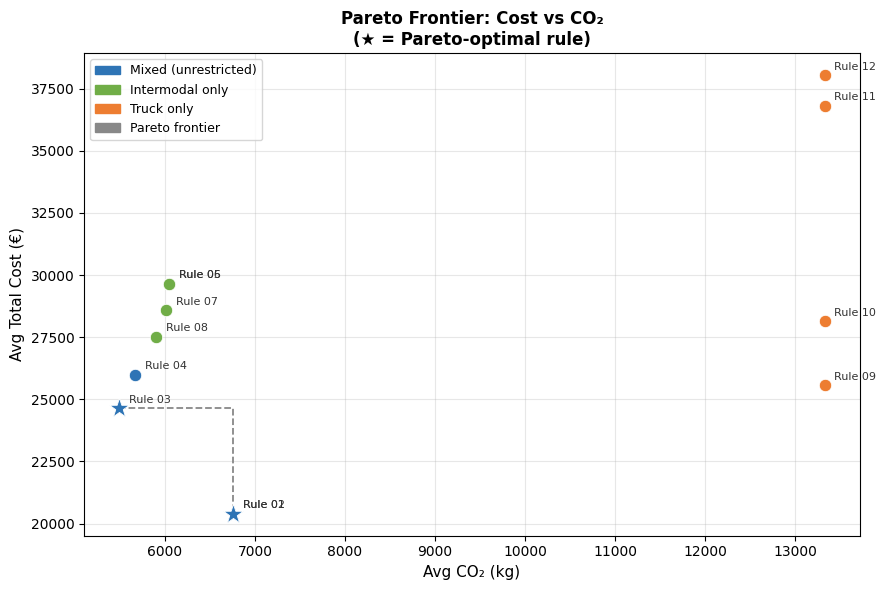

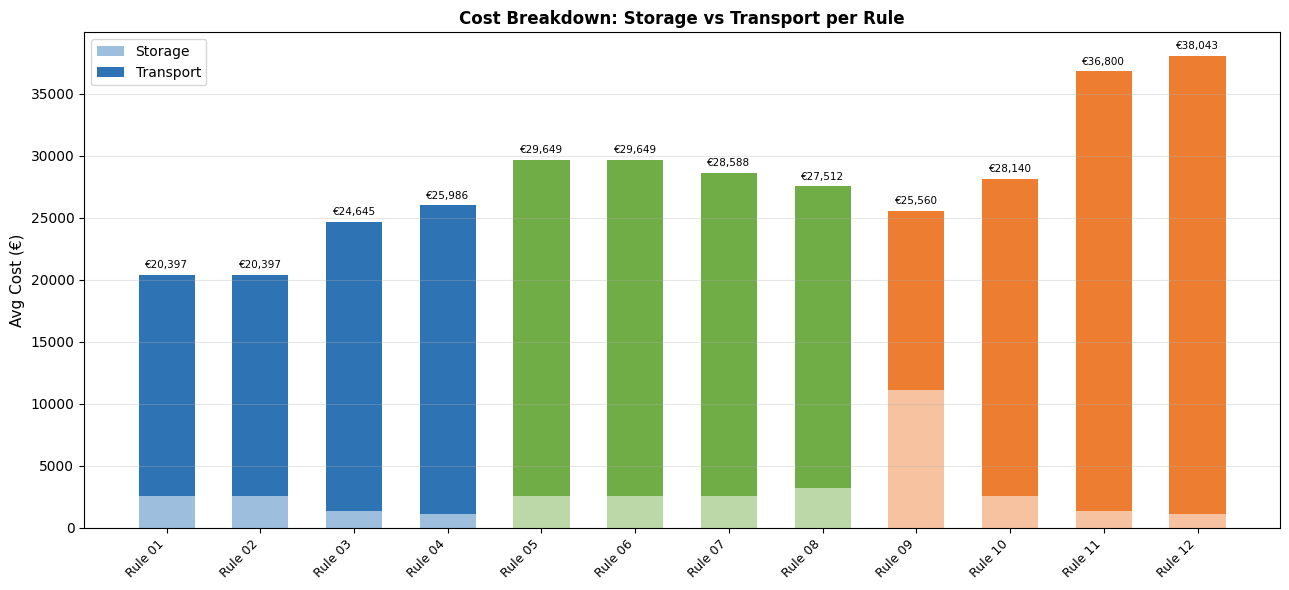

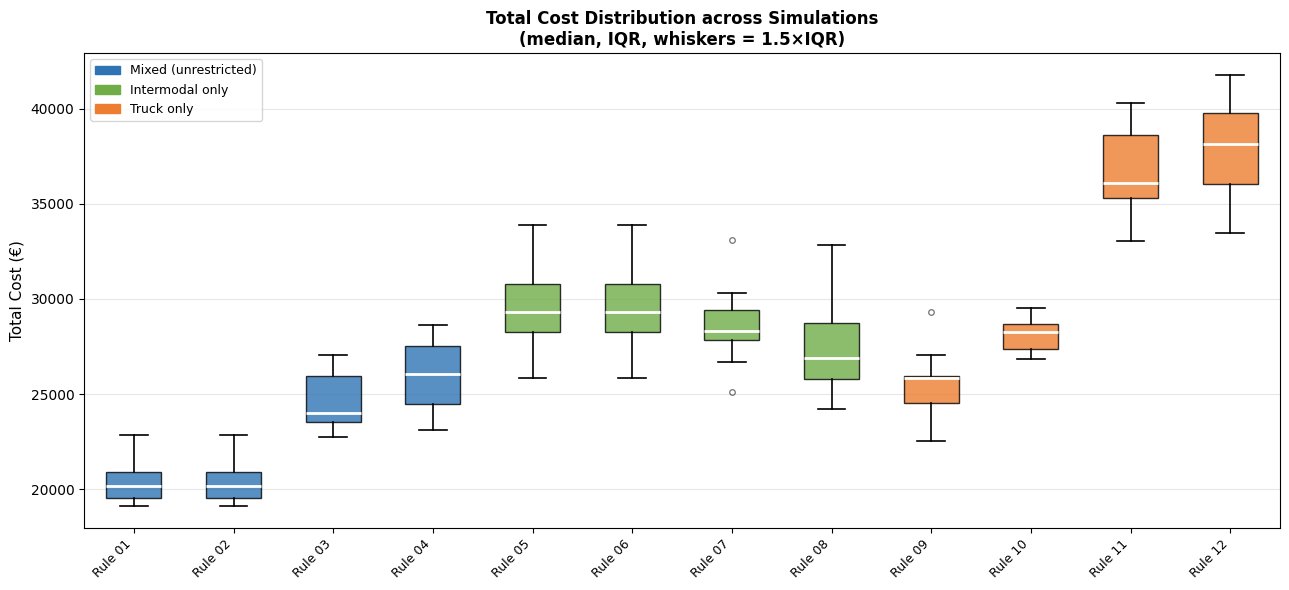

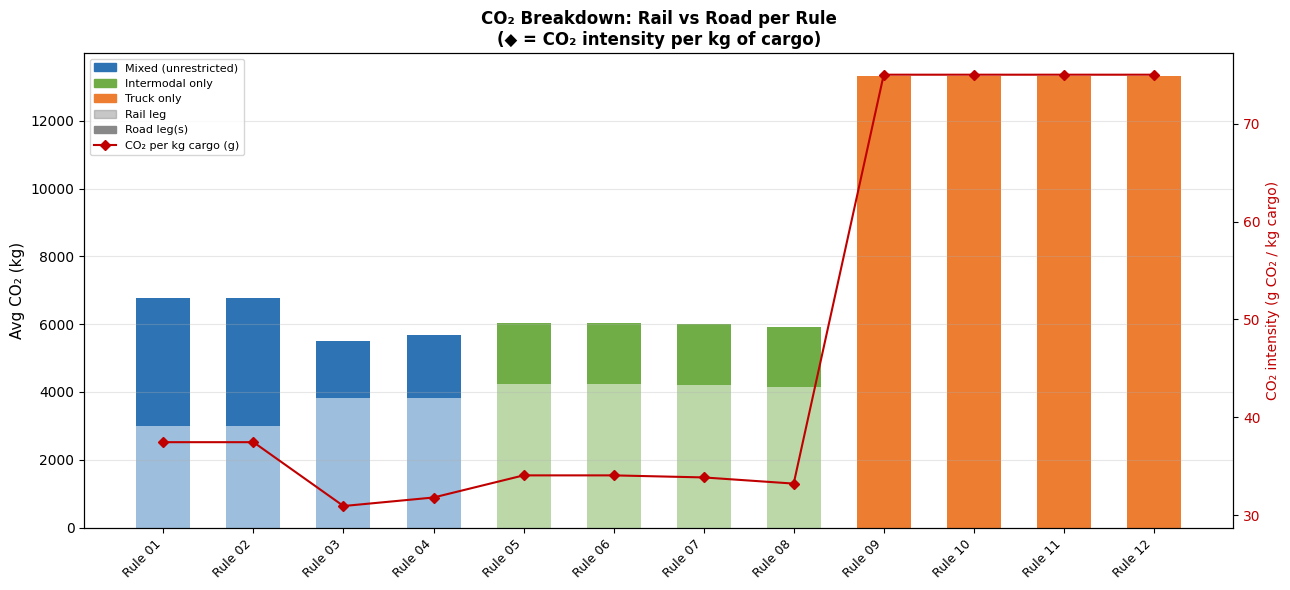

In [34]:
summary, raw = run_optimization(COSTS)
plot_all(summary, raw)

## Final Remarks

Looks good to me